In [1]:
import sys
sys.path.append("..")

from qutip_solver import simulate_heisenberg
from naive_adc_circuit import naive_circuit
from qiskit_solver import solve_qc

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

from qiskit_aer import AerSimulator

In [2]:
n = 3
J = [1/4]*(n - 1)
gamma = [J[0]/4]*n
tlist = np.linspace(0, 25, 100)
excited = ["0"]
k = [2, 8, 15]
dissipation = True
obs = "populations"

backend = AerSimulator()

pops, result = simulate_heisenberg(J, gamma, n, excited, tlist, dissipation, obs)

all_trotter = { f'k = {trotter}' : None for trotter in k }
for trotter in k:
    qc = naive_circuit(J, gamma, n, excited, trotter, dissipation)
    evs = solve_qc(n, qc, tlist, obs, backend)
    all_trotter[f'k = {trotter}'] = evs

Static multiproduct formula

In [9]:
from qiskit_addon_mpf.static import setup_static_lse
from qiskit_addon_mpf.costs import setup_exact_problem

lse = setup_static_lse(k, order=1)
model_exact, coeffs_exact = setup_exact_problem(lse)
model_exact.solve()
coeffs = coeffs_exact.value

smp_evs = { str(i) : [] for i in range(n) }
for i in range(n):
    for (idx, instant) in enumerate(tlist):
        rcnstr_evs = coeffs[0]*all_trotter[f'k = {k[0]}'][str(i)][idx] + coeffs[1]*all_trotter[f'k = {k[1]}'][str(i)][idx] + coeffs[2]*all_trotter[f'k = {k[2]}'][str(i)][idx]
        smp_evs[str(i)].append(rcnstr_evs)

Load dynamic multiproduct formula coefficients

In [10]:
coeffs = []
for i in range(len(k)):
    coeffs.append(np.loadtxt("../oqs_generalization/n_3_mpf_coefficients_3815.txt", usecols= i + 1))

dmp_evs = { str(i) : [] for i in range(n) }
for i in range(n):
    for (idx, instant) in enumerate(tlist):
        rcnstr_evs = coeffs[0][idx]*all_trotter[f'k = {k[0]}'][str(i)][idx] + coeffs[1][idx]*all_trotter[f'k = {k[1]}'][str(i)][idx] + coeffs[2][idx]*all_trotter[f'k = {k[2]}'][str(i)][idx]
        dmp_evs[str(i)].append(rcnstr_evs)

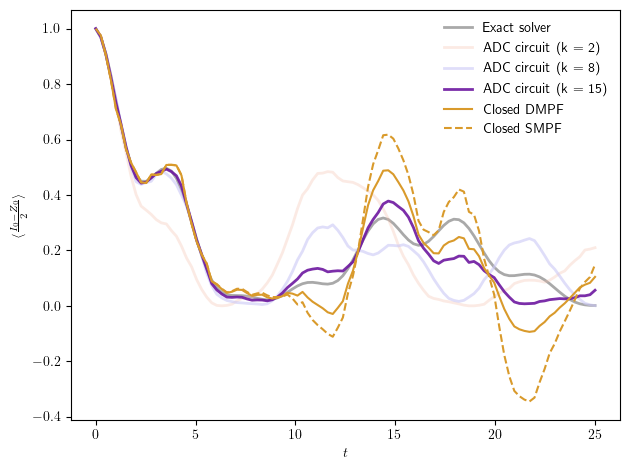

In [15]:
plot_qubits = [0]
colors = ["#f4bca6", "#cbc8f6", "#6c169f"]
for i in plot_qubits:
    plt.plot(tlist, pops[i], color = 'darkgrey', linewidth = 2, label = "Exact solver")
    alpha = 0.3
    for (idx, trotter) in enumerate(k):
        plt.plot(tlist, all_trotter[f'k = {trotter}'][str(i)], color = colors[idx], linewidth = 2, alpha = alpha, label = f"ADC circuit (k = {trotter})")
        alpha = alpha + 0.3
    plt.plot(tlist, dmp_evs[str(i)], color = "#d99a2b", label = "Closed DMPF")
    plt.plot(tlist, smp_evs[str(i)], color = "#d99a2b", linestyle = 'dashed', label = "Closed SMPF")

plt.ylabel(r"$\langle \frac{I_0 - Z_0}{2} \rangle$")
# plt.ylabel(r"$\langle Z_0Z_1 \rangle$")
#plt.ylim([0,1])
plt.xlabel("$t$")
plt.legend(frameon = False)
plt.tight_layout()
plt.savefig("[3Q]SMPF_vs_DMPF_populations.png", bbox_inches='tight', transparent = True)
plt.show()

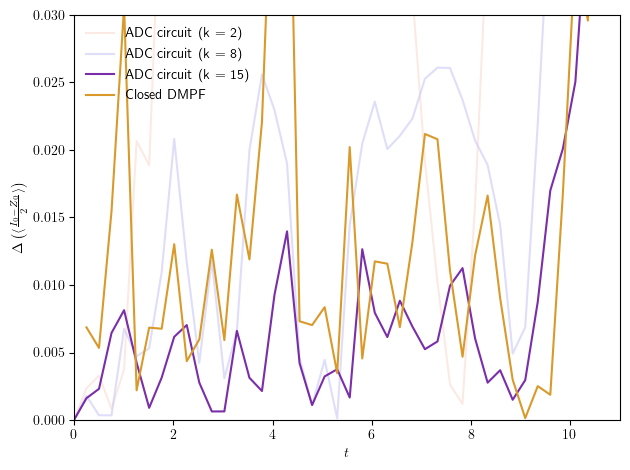

In [16]:
plot_qubits = [0]
for i in plot_qubits:
    alpha = 0.3
    for (idx, trotter) in enumerate(k):
        plt.plot(tlist, np.abs(all_trotter[f'k = {trotter}'][str(i)] - pops[i]), color = colors[idx], alpha = alpha, label = f"ADC circuit (k = {trotter})")
        alpha = alpha + 0.3
    plt.plot(tlist, np.abs(dmp_evs[str(i)] - pops[i]), color = "#d99a2b", label = "Closed DMPF")

plt.ylabel(r"$\Delta \left( \langle \frac{I_0 - Z_0}{2} \rangle \right)$")
plt.xlim([0,11])
#plt.yscale("log")
plt.ylim([0, 0.03])
plt.xlabel("$t$")
plt.legend(frameon = False)
plt.savefig("[3Q][ERROR]DMPF_populations.png", bbox_inches='tight', transparent = True)
plt.tight_layout()
plt.show()